## Agentic RAG

In [10]:
import os
from typing import List,Annotated
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


# Load ENV

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="qwen/qwen3.6-27b",
    model_provider="groq",
    temperature=0
)

llm.invoke("Hi")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n4.  **Draft Response (Mental):** "Hello! How can I help you today?" or "Hi there! What\'s on your mind?" or "Hello! I\'m here to help. What can I do for you?"\n5.  **Refine Response:** Keep it friendly, concise, and inviting. "Hello! How can I assist you today?" works well.\n6.  **Final Output Generation:** Match the refined response.✅\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 201, 'prompt_tokens': 11, 'total_tokens': 212, 'completion_time': 0.491279651, 'prompt_time': 0.000139268, 'queue_t

## Document loading from the web

In [5]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())

docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

## Recursive Character Splitter and Vectorstore

In [8]:
splitter = RecursiveCharacterTextSplitter(chunk_size =500, chunk_overlap = 50)
split_docs = splitter.split_documents(docs)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vectorestore = FAISS.from_documents(split_docs,embeddings)
retriver = vectorestore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10377.95it/s]


In [9]:
retriver.invoke("what is video")

[Document(id='70c9831f-e7a5-4839-8eec-7c78ae969581', metadata={'source': 'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/', 'title': "Diffusion Models for Video Generation | Lil'Log", 'description': 'Diffusion models have demonstrated strong results on image synthesis in past years. Now the research community has started working on a harder task—using it for video generation. The task itself is a superset of the image case, since an image is a video of 1 frame, and it is much more challenging because:\n\nIt has extra requirements on temporal consistency across frames in time, which naturally demands more world knowledge to be encoded into the model.\nIn comparison to text or images, it is more difficult to collect large amounts of high-quality, high-dimensional video data, let along text-video pairs.\n\n\n\n🥑 Required Pre-read: Please make sure you have read the previous blog on “What are Diffusion Models?” for image generation before continue here.\n', 'language': 'en-u

## RAG State

In [11]:
class RAGstate(BaseModel):
    question:str
    retrieved_docs: List[Document] = []
    answer:str=""

### Langgraph nodes

In [18]:
def retrive_docs(state: RAGstate) -> RAGstate:
    docs = retriver.invoke(state.question)
    return RAGstate(question=state.question,retrieved_docs=docs)

def generate_answers(state: RAGstate) -> RAGstate:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)

    return RAGstate(question=state.question, retrieved_docs=state.retrieved_docs, answer=response.content)

## Build the Graph

In [19]:
builder = StateGraph(RAGstate)

builder.add_node("retriver", retrive_docs)
builder.add_node("responder", generate_answers)

builder.set_entry_point("retriver")
builder.add_edge("retriver","responder")
builder.add_edge("responder",END)

graph = builder.compile()



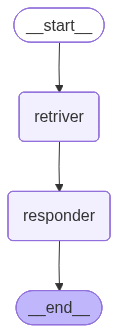

In [16]:
graph

## Run the Agentic RAG

In [21]:
if __name__ == "__main__":
    user_question = "What is the concept of agent loop in autonomous agents?"
    initial_state = RAGstate(question=user_question)
    final_state = graph.invoke(initial_state)

    print("\n✅ Final Answer: \n", final_state['answer'])



✅ Final Answer: 
 
<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Context:** Provided text snippets about planning, relationships between agents, environment information in a tree structure, generative agent architecture, LLM-powered autonomous agents, agent system overview, RL learning process, and a citation.
   - **Question:** "What is the concept of agent loop in autonomous agents?"
   - **Task:** Answer the question based *only* on the provided context.

2.  **Scan Context for Keywords:**
   - Keywords: "agent loop", "loop", "autonomous agents", "concept"
   - Scanning the context:
     - "Planning is essentially in order to optimize believability at the moment vs in time."
     - "Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)"
     - "Relationships between agents and observations of one agent by another are all taken into consideration for planning and reacting."
     - "Environment information is present in a tree st

In [22]:
final_state

{'question': 'What is the concept of agent loop in autonomous agents?',
 'retrieved_docs': [Document(id='5028e9c5-8276-417d-a777-5327a2a3757a', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism an